In [ ]:
# conda activate genomic_tools

import os
import pickle
import pandas as pd
from collections import defaultdict
from matplotlib.backends.backend_pdf import PdfPages

pd.set_option('display.max_columns', None)

In [ ]:
# if an event is cell type-specific, and it has a exon_diff_boundary or exon_diff_junction transcript, I need to know if:

# (1) the transcript was emitted and 
# (2) it is also cell type-specific.

# this is important because it means that any overlapping domains of interest are not necessarily cell type-specific.

# to interpret results, I will plot not only the transcript with the event, but also variants of that event.

In [ ]:
with open("data/gencode.v46.annotation_cds_by_transcript.pkl", "rb") as f:
    cds_by_transcript = pickle.load(f)

In [ ]:
# Load in event-interproscan results mapping

with open('data/event_interproscan_map.pkl', "rb") as f:
    event_interproscan_map = pickle.load(f)
    
with open("data/signif_event_interproscan_map.pkl", "rb") as f:
    signif_event_interproscan_map = pickle.load(f)
    
with open("data/signif_event_interproscan_summary.pkl", "rb") as f:
    signif_event_interproscan_summary = pickle.load(f)

# Plot

In [70]:
"""
plot_domain_structure.py  —  v4  (compressed-intron, flanking-exon aware)

Two stacked panels per event:
  Top    : genome-coordinate view (exon/intron structure)
  Bottom : domain structure, one row per isoform

X-axis uses a piecewise transform:
  [left flanking exon CDS] -- //compressed// -- [cassette exon] -- //compressed// -- [right flanking exon CDS]

Inputs: event_interproscan_map, signif_event_interproscan_map,
        cds_by_transcript, ctype
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, FancyBboxPatch


ANALYSIS_COLORS = {
    'Pfam':             '#4E79A7',
    'SMART':            '#F28E2B',
    'SUPERFAMILY':      '#E15759',
    'CDD':              '#76B7B2',
    'PROSITE profiles': '#59A14F',
    'PROSITE patterns': '#EDC948',
    'Phobius':          '#B07AA1',
    'DeepTMHMM':        '#FF9DA7',
    'CATH-Gene3D':      '#9C755F',
    'CATH-FunFam':      '#BAB0AC',
    'SignalP':          '#D37295',
    'TMbed':            '#E8735A',
    'COILS':            '#A0CBE8',
    'PIRSR':            '#8CD17D',
}
DEFAULT_COLOR = '#bbbbbb'

# fraction of total plot width allocated to each compressed intron stub
INTRON_FRAC = 0.08


def _acolor(analysis):
    return ANALYSIS_COLORS.get(analysis, DEFAULT_COLOR)


def _first(df, col, default=None):
    if df is None or (hasattr(df, 'empty') and df.empty):
        return default
    vals = df[col].dropna() if col in df.columns else pd.Series(dtype=object)
    return vals.iloc[0] if not vals.empty else default


def _cds_rows_sorted(cds_obj, strand):
    """Return CDS rows as list of dicts, sorted in translation order."""
    if cds_obj is None:
        return []
    if hasattr(cds_obj, 'iterrows'):
        rows = [{'start': int(r['start']), 'end': int(r['end'])}
                for _, r in cds_obj.iterrows()]
    else:
        rows = [{'start': int(c['start']), 'end': int(c['end'])} for c in cds_obj]
    return sorted(rows, key=lambda r: r['start'],
                  reverse=(strand == '-'))


def _flanking_exon_extents(transcript, exon_cds_start, exon_cds_end,
                           strand, cds_by_transcript):
    """
    Return (upstream_cds_start, upstream_cds_end,
            downstream_cds_start, downstream_cds_end)
    for the exons immediately flanking the cassette exon in the given transcript.
    Returns None for a flank if the cassette exon is terminal.
    """
    rows = _cds_rows_sorted(cds_by_transcript.get(transcript), strand)
    if not rows:
        return None, None, None, None

    # find the CDS row(s) that correspond to the cassette exon
    cassette_idx = None
    for i, r in enumerate(rows):
        if r['start'] == exon_cds_start and r['end'] == exon_cds_end:
            cassette_idx = i
            break
        # partially overlapping (partially_coding case)
        if r['start'] <= exon_cds_end and r['end'] >= exon_cds_start:
            cassette_idx = i
            break

    if cassette_idx is None:
        return None, None, None, None

    up_row   = rows[cassette_idx - 1] if cassette_idx > 0 else None
    down_row = rows[cassette_idx + 1] if cassette_idx < len(rows) - 1 else None

    up_s   = up_row['start']   if up_row   else None
    up_e   = up_row['end']     if up_row   else None
    dn_s   = down_row['start'] if down_row else None
    dn_e   = down_row['end']   if down_row else None

    return up_s, up_e, dn_s, dn_e


# ── piecewise coordinate transform ────────────────────────────────────────
class PiecewiseTransform:
    """
    Maps genomic coordinates to plot x using a piecewise linear transform.

    Segments (in left-to-right plot order, each segment is a genomic interval):
      [(g_start, g_end, plot_frac), ...]
    plot_frac is the fraction of total plot width this segment occupies.

    For minus-strand genes, genomic coordinates are reversed before applying
    the transform (so transcription 5'->3' always maps left->right).
    """
    def __init__(self, segments, total_width=1000.0, strand='+'):
        self.strand      = strand
        self.total_width = total_width
        # for minus strand, reverse segment order and flip coordinates
        if strand == '-':
            segments = [(g_end, g_start, frac)
                        for g_start, g_end, frac in reversed(segments)]
        self.segments = segments
        # precompute cumulative plot positions
        self.seg_px = []
        x = 0.0
        for g_s, g_e, frac in segments:
            w = frac * total_width
            self.seg_px.append((x, x + w))
            x += w

    def __call__(self, g_pos):
        """Map a single genomic position to plot x."""
        for i, (g_s, g_e, frac) in enumerate(self.segments):
            px_s, px_e = self.seg_px[i]
            if g_s <= g_pos <= g_e:
                t = (g_pos - g_s) / max(g_e - g_s, 1)
                return px_s + t * (px_e - px_s)
        # outside all segments — clamp
        if g_pos < self.segments[0][0]:
            return self.seg_px[0][0]
        return self.seg_px[-1][1]

    @property
    def compressed_zones(self):
        """Return list of (px_start, px_end) for compressed intron segments."""
        return [self.seg_px[i] for i, (_, _, frac) in enumerate(self.segments)
                if frac == INTRON_FRAC]


def _build_transform(exon_cds_start, exon_cds_end, strand,
                     up_s, up_e, dn_s, dn_e, total_width=1000.0):
    """
    Build the piecewise transform given cassette exon and flanking exon extents.
    Returns (PiecewiseTransform, g_left, g_right).
    """
    # left and right genomic extents (in + strand orientation)
    if strand == '+':
        left_start  = up_s  if up_s  is not None else exon_cds_start - 10
        left_end    = up_e  if up_e  is not None else exon_cds_start - 1
        right_start = dn_s  if dn_s  is not None else exon_cds_end + 1
        right_end   = dn_e  if dn_e  is not None else exon_cds_end + 10
    else:
        # minus strand: translation order is reversed
        # upstream (5') flank is genomically to the RIGHT of the cassette exon
        left_start  = up_s  if up_s  is not None else exon_cds_end + 1
        left_end    = up_e  if up_e  is not None else exon_cds_end + 10
        right_start = dn_s  if dn_s  is not None else exon_cds_start - 10
        right_end   = dn_e  if dn_e  is not None else exon_cds_start - 1

    g_left  = min(left_start,  left_end,  exon_cds_start, exon_cds_end)
    g_right = max(right_start, right_end, exon_cds_start, exon_cds_end)

    # available fracs after intron stubs
    has_left  = (up_s is not None)
    has_right = (dn_s is not None)
    n_introns = has_left + has_right
    intron_total = n_introns * INTRON_FRAC
    coding_total = 1.0 - intron_total

    # split coding_total among left flank, cassette, right flank
    left_width  = abs(left_end  - left_start)
    exon_width  = abs(exon_cds_end - exon_cds_start)
    right_width = abs(right_end - right_start)
    total_coding_nt = left_width + exon_width + right_width or 1

    left_frac  = coding_total * left_width  / total_coding_nt
    exon_frac  = coding_total * exon_width  / total_coding_nt
    right_frac = coding_total * right_width / total_coding_nt

    segments = []
    if strand == '+':
        if has_left:
            segments.append((left_start, left_end,     left_frac))
            segments.append((left_end,   exon_cds_start, INTRON_FRAC))
        segments.append((exon_cds_start, exon_cds_end, exon_frac))
        if has_right:
            segments.append((exon_cds_end, right_start, INTRON_FRAC))
            segments.append((right_start, right_end,    right_frac))
    else:
        # minus strand segments in genomic-ascending order;
        # PiecewiseTransform will reverse them
        if has_right:   # downstream in translation = right in genomic
            segments.append((right_start, right_end,    right_frac))
            segments.append((right_end,   exon_cds_start, INTRON_FRAC))
        segments.append((exon_cds_start, exon_cds_end, exon_frac))
        if has_left:
            segments.append((exon_cds_end, left_start,  INTRON_FRAC))
            segments.append((left_start, left_end,      left_frac))

    tfm = PiecewiseTransform(segments, total_width=total_width, strand=strand)
    return tfm, g_left, g_right


# ── domain track drawing ───────────────────────────────────────────────────
def _pack_tracks(intervals, max_tracks=4):
    intervals = sorted(intervals, key=lambda x: x[0])
    tracks = []
    row_to_track = {}
    for s, e, idx in intervals:
        placed = False
        for ti, track in enumerate(tracks):
            if track < s:
                tracks[ti] = e
                row_to_track[idx] = ti
                placed = True
                break
        if not placed and len(tracks) < max_tracks:
            tracks.append(e)
            row_to_track[idx] = len(tracks) - 1
    return row_to_track


def _aa_to_genomic(aa_pos, aa_ref, cds_start, cds_end, strand):
    nt_offset = (aa_pos - aa_ref) * 3
    if strand == '+':
        return cds_start + nt_offset
    else:
        return cds_end - nt_offset


def _draw_domains(ax, df, aa_ref, cds_start, cds_end, strand, tfm,
                  y_center, direction=1, track_h=0.22,
                  gap=0.08, max_tracks=4, alpha=0.85, label_fontsize=7):
    if df is None or (hasattr(df, 'empty') and df.empty):
        return
    df = df.reset_index(drop=True)
    intervals = []
    for i, row in df.iterrows():
        g_s = _aa_to_genomic(row['start'], aa_ref, cds_start, cds_end, strand)
        g_e = _aa_to_genomic(row['stop'],  aa_ref, cds_start, cds_end, strand)
        px_s = tfm(min(g_s, g_e))
        px_e = tfm(max(g_s, g_e))
        intervals.append((px_s, px_e, i))

    row_to_track = _pack_tracks(intervals, max_tracks=max_tracks)

    for px_s, px_e, i in intervals:
        ti = row_to_track.get(i)
        if ti is None:
            continue
        row = df.iloc[i]
        y = y_center + direction * (gap + ti * (track_h + 0.45) + track_h / 2)
        color = _acolor(row.get('analysis', ''))
        w = max(px_e - px_s, 1)
        ax.add_patch(FancyBboxPatch(
            (px_s, y - track_h / 2), w, track_h,
            boxstyle='round,pad=0.3',
            facecolor=color, edgecolor='none',
            alpha=alpha, zorder=4
        ))
        label = str(row.get('signature_description') or
                    row.get('interpro_description') or '')
        if label and label.strip('-').strip() and w > 15:
            short = label[:18] + '…' if len(label) > 18 else label
            ax.text(px_s + w / 2, y, short,
                    ha='center', va='center',
                    fontsize=label_fontsize,
                    color='#333333', fontweight='bold',
                    zorder=6, clip_on=True)

    # no right-side column needed
    max_y = max(
        (y_center + direction * (gap + ti * (track_h + 0.45) + track_h / 2)
         for ti in row_to_track.values()),
        default=y_center
    )
    return max_y



# ── helpers ────────────────────────────────────────────────────────────────
def _draw_compression_shading(ax, tfm, y_min, y_max):
    """Shade compressed intron zones with light grey."""
    for px_s, px_e in tfm.compressed_zones:
        ax.axvspan(px_s, px_e, color='#f0f0f0', zorder=0, alpha=1.0)


def _get_gene_name(ev, signif_event_interproscan_map, ctype):
    for ct in ([ctype] + [c for c in signif_event_interproscan_map if c != ctype]):
        df = signif_event_interproscan_map.get(ct)
        if df is None:
            continue
        rows = df[df['event_id'] == ev]
        if not rows.empty and 'Gene' in rows.columns:
            val = rows['Gene'].dropna()
            if not val.empty:
                return str(val.iloc[0])
    return ''


def _get_ctype_annotation(ev, transcript, bucket,
                          signif_event_interproscan_map, ctype):
    """
    r is a per-event property (exon PSI correlation with cell type abundance),
    not per-transcript. Look up by event_id only across all cell types.
    """
    r = is_specific = None
    other_ctypes = []

    def _lookup(df):
        if df is None:
            return None, None
        rows = df[df['event_id'] == ev]
        if not rows.empty:
            return rows['r'].iloc[0], rows['is_specific'].iloc[0]
        return None, None

    r, is_specific = _lookup(signif_event_interproscan_map.get(ctype))

    for ct, df in signif_event_interproscan_map.items():
        if ct == ctype:
            continue
        ct_r, _ = _lookup(df)
        if ct_r is not None:
            other_ctypes.append((ct, ct_r))

    return r, is_specific, other_ctypes


def _is_nan(v):
    """Check for None or float NaN."""
    return v is None or (isinstance(v, float) and v != v)


# ── main entry point ────────────────────────────────────────────────────────
def plot_event_domains(ev, event_interproscan_map, signif_event_interproscan_map,
                       cds_by_transcript, ctype,
                       intron_frac=INTRON_FRAC, fontscale=1.0,
                       figsize=None, save_path=None, dpi=150):
    """
    Parameters
    ----------
    ev                            : event ID
    event_interproscan_map        : dict  ev -> {bucket: DataFrame}
    signif_event_interproscan_map : dict  ctype -> long-form DataFrame
    cds_by_transcript             : dict  transcript_id -> CDS DataFrame/list
    ctype                         : focal cell type
    intron_frac                   : fraction of plot width per compressed intron
    figsize / save_path / dpi     : matplotlib args
    """
    global INTRON_FRAC
    INTRON_FRAC = intron_frac

    # scale all font sizes
    base = 6.0 * fontscale
    plt.rcParams.update({
        'font.size':        base,
        'axes.titlesize':   base * 1.1,
        'axes.labelsize':   base,
        'xtick.labelsize':  base * 0.9,
        'ytick.labelsize':  base * 0.9,
        'legend.fontsize':  base * 0.9,
    })

    ipr_rec = event_interproscan_map.get(ev, {})
    incl_df = ipr_rec.get('inclusion')
    if incl_df is None or incl_df.empty:
        print(f"{ev}: no inclusion data")
        return None

    aa_start  = _first(incl_df, 'aa_start')
    aa_end    = _first(incl_df, 'aa_end')
    cds_start = int(_first(incl_df, 'exon_cds_start', 0))
    cds_end   = int(_first(incl_df, 'exon_cds_end',   0))
    incl_t    = _first(incl_df, 'protein_accession', '')
    gene_name = _get_gene_name(ev, signif_event_interproscan_map, ctype)

    # chrom and strand from signif_event_interproscan_map
    chrom  = ''
    strand = '+'
    for ct_df in signif_event_interproscan_map.values():
        if ct_df is None:
            continue
        rows = ct_df[ct_df['event_id'] == ev]
        if not rows.empty:
            if 'chr' in ct_df.columns:
                chrom = str(rows['chr'].iloc[0])
            if 'strand' in ct_df.columns:
                strand = str(rows['strand'].iloc[0])
            break
    # fallback to inclusion df
    if not chrom:
        chrom  = _first(incl_df, 'chrom', '')
    if strand == '+':
        strand = _first(incl_df, 'strand', '+')

    # get flanking exon extents from inclusion transcript
    up_s, up_e, dn_s, dn_e = _flanking_exon_extents(
        incl_t, cds_start, cds_end, strand, cds_by_transcript
    )

    # compute genomic extent of ALL domain hits across all buckets
    # so that skip/sibling domains outside the cassette exon region are visible
    all_g_coords = []
    for bucket_df in ipr_rec.values():
        if bucket_df is None or (hasattr(bucket_df, 'empty') and bucket_df.empty):
            continue
        b_aa_start = bucket_df['aa_start'].iloc[0] if 'aa_start' in bucket_df.columns else None
        b_cds_s    = int(bucket_df['exon_cds_start'].iloc[0]) if 'exon_cds_start' in bucket_df.columns else cds_start
        b_cds_e    = int(bucket_df['exon_cds_end'].iloc[0])   if 'exon_cds_end'   in bucket_df.columns else cds_end
        if _is_nan(b_aa_start):
            b_aa_start = bucket_df['truncation_aa'].iloc[0] if 'truncation_aa' in bucket_df.columns else None
        if b_aa_start is None or _is_nan(b_aa_start):
            continue
        for _, row in bucket_df.iterrows():
            g_s = _aa_to_genomic(row['start'], b_aa_start, b_cds_s, b_cds_e, strand)
            g_e = _aa_to_genomic(row['stop'],  b_aa_start, b_cds_s, b_cds_e, strand)
            all_g_coords.extend([g_s, g_e])

    # expand flanking exon extents to cover all domain hits
    if all_g_coords:
        domain_g_min = min(all_g_coords)
        domain_g_max = max(all_g_coords)
        if strand == '+':
            if up_s is None or domain_g_min < up_s:
                up_s = int(domain_g_min)
            if up_e is None or domain_g_min < up_s:
                up_e = int(min(domain_g_min, cds_start - 1))
            if dn_e is None or domain_g_max > dn_e:
                dn_e = int(domain_g_max)
            if dn_s is None:
                dn_s = int(cds_end + 1)
        else:
            if up_e is None or domain_g_max > up_e:
                up_e = int(domain_g_max)
            if up_s is None:
                up_s = int(cds_end + 1)
            if dn_s is None or domain_g_min < dn_s:
                dn_s = int(domain_g_min)
            if dn_e is None:
                dn_e = int(cds_start - 1)

    # build shared coordinate transform
    tfm, g_left, g_right = _build_transform(
        cds_start, cds_end, strand, up_s, up_e, dn_s, dn_e, total_width=1000.0
    )
    plot_width = 1000.0

    # ── assemble isoform buckets ───────────────────────────────────────────
    # bucket_defs: (key, color, is_skip, show_ctype)
    # skips: no ctype annotation
    # inclusion: ctype by event_id
    # siblings: ctype by protein_accession (transcript) across all cell types
    bucket_defs = [
        ('inclusion',                   '#F28E2B', False, True),
        ('real_skip',                   '#4E79A7', True,  False),
        ('synthetic_skip',              '#76B7B2', True,  False),
        ('exon_diff_boundary_siblings', '#59A14F', False, True),
        ('exon_diff_junction_siblings', '#B07AA1', False, True),
    ]

    buckets = []
    for bucket_key, color, is_skip, show_ctype in bucket_defs:
        df = ipr_rec.get(bucket_key)
        if df is None or (hasattr(df, 'empty') and df.empty):
            continue
        transcripts = (df['protein_accession'].unique()
                       if 'protein_accession' in df.columns else [None])
        for t in transcripts:
            tdf = df[df['protein_accession'] == t] if t is not None else df
            b_aa_start  = _first(tdf, 'aa_start')
            b_aa_end    = _first(tdf, 'aa_end')

            if _is_nan(b_aa_start):
                b_aa_start = _first(tdf, 'truncation_aa')
                b_aa_end   = b_aa_start

            b_cds_start = int(_first(tdf, 'exon_cds_start') or cds_start)
            b_cds_end   = int(_first(tdf, 'exon_cds_end')   or cds_end)
            trunc_aa    = _first(tdf, 'truncation_aa') if is_skip else None
            frame_pres  = _first(tdf, 'frame_preserving') if is_skip else None
            if frame_pres:
                trunc_aa = None

            # ctype annotation:
            # inclusion  -> look up by event_id
            # siblings   -> look up by protein_accession across all cell types
            # skips      -> suppressed
            if not show_ctype:
                r = specific = None
                others = []
            elif bucket_key == 'inclusion':
                r, specific, others = _get_ctype_annotation(
                    ev, t, bucket_key, signif_event_interproscan_map, ctype
                )
            else:
                # sibling: find which cell types have this transcript
                # signif_event_interproscan_map only contains significant events
                # so any match is already a significant association
                r = specific = None
                others = []
                seen_cts = set()
                for ct, ct_df in signif_event_interproscan_map.items():
                    if ct_df is None or 'protein_accession' not in ct_df.columns:
                        continue
                    if ct in seen_cts:
                        continue
                    rows = ct_df[ct_df['protein_accession'] == t]
                    if rows.empty:
                        continue
                    seen_cts.add(ct)
                    ct_r = rows['r'].iloc[0]
                    ct_spec = rows['is_specific'].iloc[0]
                    if ct == ctype:
                        r, specific = ct_r, ct_spec
                    else:
                        others.append((ct, ct_r))

            buckets.append({
                'bucket':       bucket_key,
                'label':        f"{bucket_key.replace('_', ' ')}\n{t}",
                'transcript':   t,
                'aa_start':     b_aa_start,
                'aa_end':       b_aa_end,
                'cds_start':    b_cds_start,
                'cds_end':      b_cds_end,
                'exon_color':   color,
                'domains':      tdf,
                'truncation':   trunc_aa,
                'r':            r,
                'is_specific':  specific,
                'other_ctypes': others,
                'is_skip':      is_skip,
                'show_ctype':   show_ctype,
            })

    if not buckets:
        print(f"{ev}: no buckets to plot")
        return None

    # pre-estimate number of tracks per bucket for variable panel heights
    def _estimate_tracks(domains_df):
        if domains_df is None or (hasattr(domains_df, 'empty') and domains_df.empty):
            return 1
        n = len(domains_df)
        return min(n, 12)   # rough upper bound

    row_heights = [max(1.5, _estimate_tracks(b['domains']) * 0.6) for b in buckets]

    # ── figure ─────────────────────────────────────────────────────────────
    n_iso = len(buckets)
    fw = figsize[0] if figsize else 18
    fh = figsize[1] if figsize else max(5, 2.0 + sum(row_heights))

    fig = plt.figure(figsize=(fw, fh))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[1, sum(row_heights)],
                             hspace=0.05, figure=fig)
    ax_top = fig.add_subplot(gs[0])
    gs_iso = gridspec.GridSpecFromSubplotSpec(
        n_iso, 1, subplot_spec=gs[1], hspace=0.05,
        height_ratios=row_heights
    )
    iso_axes = [fig.add_subplot(gs_iso[i]) for i in range(n_iso)]

    # title
    coord_str   = f"{chrom}:{cds_start}-{cds_end}" if chrom else ''
    title_parts = [ev]
    if gene_name and gene_name != ev:
        title_parts.append(gene_name)
    title_parts += [coord_str, f"cell type: {ctype}"]
    fig.suptitle("  |  ".join(p for p in title_parts if p),
                 fontsize=base * 1.33, y=1.01)

    # ── TOP PANEL: genome structure ────────────────────────────────────────
    ax = ax_top
    exon_px_s = tfm(cds_start)
    exon_px_e = tfm(cds_end)
    exon_pw   = exon_px_e - exon_px_s

    # intron lines to left and right edges
    if up_s is not None:
        left_px = tfm(up_s if strand == '+' else up_e)
        ax.plot([left_px, exon_px_s], [0, 0], color='#aaaaaa', lw=1, zorder=1)
    if dn_s is not None:
        right_px = tfm(dn_e if strand == '+' else dn_s)
        ax.plot([exon_px_e, right_px], [0, 0], color='#aaaaaa', lw=1, zorder=1)

    # flanking exon stubs
    stub_h = 0.25
    if up_s is not None:
        up_px_s = tfm(up_s if strand == '+' else up_e)
        up_px_e = tfm(up_e if strand == '+' else up_s)
        ax.add_patch(Rectangle((min(up_px_s, up_px_e), -stub_h / 2),
                                abs(up_px_e - up_px_s), stub_h,
                                facecolor='#cccccc', edgecolor='none', zorder=2))
    if dn_s is not None:
        dn_px_s = tfm(dn_s if strand == '+' else dn_e)
        dn_px_e = tfm(dn_e if strand == '+' else dn_s)
        ax.add_patch(Rectangle((min(dn_px_s, dn_px_e), -stub_h / 2),
                                abs(dn_px_e - dn_px_s), stub_h,
                                facecolor='#cccccc', edgecolor='none', zorder=2))

    # cassette exon block
    ax.add_patch(Rectangle((exon_px_s, -0.3), exon_pw, 0.6,
                             facecolor='#F28E2B', edgecolor='#555555',
                             linewidth=0.7, zorder=3))
    ax.text(exon_px_s + exon_pw / 2, 0.45,
            f"exon  aa {aa_start}–{aa_end}\n{chrom}:{cds_start}-{cds_end}",
            ha='center', va='bottom', fontsize=base * 0.92, color='#333333')

    ax.text(0.01, 0.95, f"strand: {strand}", transform=ax.transAxes,
            fontsize=base * 0.83, color='#888888', va='top')
    ax.set_xlim(0, plot_width)
    ax.set_ylim(-0.9, 1.2)
    ax.set_yticks([])
    ax.tick_params(bottom=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── ISOFORM PANELS ─────────────────────────────────────────────────────
    y_bar   = 0.0
    y_above = 0.08

    for ax_iso, b in zip(iso_axes, buckets):

        # grey protein bar (full plot width = schematic)
        ax_iso.add_patch(Rectangle((0, y_bar - 0.04), plot_width, 0.08,
                                    facecolor='#e8e8e8', edgecolor='none', zorder=1))

        # flanking exon blocks (same for all isoforms, from inclusion transcript)
        flank_h = 0.10
        if up_s is not None:
            up_px_s = tfm(up_s if strand == '+' else up_e)
            up_px_e = tfm(up_e if strand == '+' else up_s)
            ax_iso.add_patch(Rectangle(
                (min(up_px_s, up_px_e), y_bar - flank_h / 2),
                abs(up_px_e - up_px_s), flank_h,
                facecolor='#cccccc', edgecolor='#888888',
                linewidth=0.4, zorder=2
            ))
            # upstream exon boundaries
            for px in (up_px_s, up_px_e):
                ax_iso.axvline(px, color='#888888', lw=0.6,
                               linestyle=':', alpha=0.8, zorder=6)
        if dn_s is not None:
            dn_px_s = tfm(dn_s if strand == '+' else dn_e)
            dn_px_e = tfm(dn_e if strand == '+' else dn_s)
            ax_iso.add_patch(Rectangle(
                (min(dn_px_s, dn_px_e), y_bar - flank_h / 2),
                abs(dn_px_e - dn_px_s), flank_h,
                facecolor='#cccccc', edgecolor='#888888',
                linewidth=0.4, zorder=2
            ))
            # downstream exon boundaries
            for px in (dn_px_s, dn_px_e):
                ax_iso.axvline(px, color='#888888', lw=0.6,
                               linestyle=':', alpha=0.8, zorder=6)

        # cassette exon block
        b_px_s = tfm(b['cds_start'])
        b_px_e = tfm(b['cds_end'])
        b_pw   = b_px_e - b_px_s
        ax_iso.add_patch(Rectangle(
            (b_px_s, y_bar - 0.06), max(b_pw, 1), 0.12,
            facecolor=b['exon_color'], edgecolor='#555555',
            linewidth=0.6, alpha=0.85, zorder=3
        ))
        # cassette exon boundary lines (solid black, more prominent)
        for px in (b_px_s, b_px_e):
            ax_iso.axvline(px, color='black', lw=0.9,
                           linestyle='--', alpha=0.9, zorder=7)

        # truncation marker — only for frame-shifting skips
        if b['truncation'] is not None:
            ref_aa  = b['aa_start'] if b['aa_start'] is not None else b['truncation']
            trunc_g  = _aa_to_genomic(b['truncation'], ref_aa,
                                       b['cds_start'], b['cds_end'], strand)
            trunc_px = tfm(trunc_g)
            ax_iso.axvline(trunc_px, color='#E15759', lw=1.2,
                           linestyle=':', alpha=0.85, zorder=7)
            ax_iso.text(trunc_px + 3, y_bar + 0.1,
                        f"frameshift / truncation\naa {b['truncation']}",
                        ha='left', va='bottom', fontsize=base * 0.67,
                        color='#E15759', zorder=8)

        # domain tracks
        max_y = y_above + 0.3  # default if no domains
        if b['aa_start'] is not None and not _is_nan(b['aa_start']) \
                and b['domains'] is not None \
                and not b['domains'].empty:
            max_y = _draw_domains(ax_iso, b['domains'],
                          aa_ref=b['aa_start'],
                          cds_start=b['cds_start'], cds_end=b['cds_end'],
                          strand=strand, tfm=tfm,
                          y_center=y_above, direction=1,
                          track_h=0.18, gap=0.05, max_tracks=12, alpha=0.9,
                          label_fontsize=base * 0.55)

        # compression marks

        ax_iso.set_xlim(0, plot_width)
        ax_iso.set_ylim(-0.6, max(max_y + 0.4, 1.0))
        ax_iso.set_yticks([])
        is_last = (ax_iso is iso_axes[-1])
        ax_iso.tick_params(axis='x', labelsize=5.5,
                           bottom=is_last, labelbottom=is_last)
        for spine in ('top', 'left', 'right'):
            ax_iso.spines[spine].set_visible(False)
        ax_iso.spines['bottom'].set_linewidth(0.5 if is_last else 0)

        # isoform label above, cell-type annotation below — both on the left
        ax_iso.text(-plot_width * 0.02, y_bar + 0.05, b['label'],
                    ha='right', va='bottom', fontsize=base * 0.92,
                    color='#333333', linespacing=1.4)

        if b['show_ctype']:
            annot_lines = []
            if b['r'] is not None:
                spec_str = ' (specific)' if str(b['is_specific']).lower() == 'true' else ' (not specific)'
                annot_lines.append(f"{ctype}: r = {float(b['r']):.2f}{spec_str}")
            for ct, ct_r in b['other_ctypes']:
                r_str = f": r = {float(ct_r):.2f}" if ct_r is not None else ''
                annot_lines.append(f"{ct}{r_str}")
            if annot_lines:
                ax_iso.text(-plot_width * 0.02, y_bar - 0.08,
                            '\n'.join(annot_lines),
                            ha='right', va='top', fontsize=base * 0.75,
                            color='#666666', linespacing=1.5, style='italic')

        ax_iso.axhline(-0.55, color='#eeeeee', lw=0.5, zorder=0)

    # x-axis ticks: label the key genomic positions
    key_positions = {
        tfm(cds_start): f"{cds_start}",
        tfm(cds_end):   f"{cds_end}",
    }
    if up_e is not None:
        key_positions[tfm(up_e   if strand=='+' else up_s)]   = f"{up_e if strand=='+' else up_s}"
    if dn_s is not None:
        key_positions[tfm(dn_s   if strand=='+' else dn_e)]   = f"{dn_s if strand=='+' else dn_e}"
    iso_axes[-1].set_xticks(list(key_positions.keys()))
    iso_axes[-1].set_xticklabels(list(key_positions.values()),
                                  rotation=30, ha='right', fontsize=base * 0.83)
    iso_axes[-1].set_xlabel(
        f"genomic position ({chrom}, {'5′→3′' if strand=='+' else '3′→5′'})",
        fontsize=base
    )
    ax_top.set_xlim(0, plot_width)

    # legend — only include analyses from buckets that will actually be drawn
    seen = set()
    for b in buckets:
        if b['domains'] is not None and \
                not (hasattr(b['domains'], 'empty') and b['domains'].empty) \
                and not _is_nan(b['aa_start']):
            seen.update(b['domains'].get('analysis', pd.Series()).unique())
    handles = [mpatches.Patch(facecolor=_acolor(a), label=a, alpha=0.85)
               for a in sorted(seen) if a in ANALYSIS_COLORS]
    if handles:
        fig.legend(handles=handles, loc='lower center',
                   ncol=min(len(handles), 7), fontsize=base * 0.92,
                   frameon=False, bbox_to_anchor=(0.5, 0.01))

    fig.subplots_adjust(left=0.15, right=0.85, top=0.95, bottom=0.06, hspace=0.05)
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"saved -> {save_path}")
    else:
        plt.show()
    return fig

In [ ]:
rec = signif_event_interproscan_map['Deep_layer_glutamatergic']

rec[rec['event_id'] == "ENSG00000056291_ProteinCoding_1"]

,event_id,bucket,protein_accession,sequence_length,analysis,signature_description,start,stop,interpro_description,aa_start,aa_end,exon_cds_start,exon_cds_end,frame_preserving,clean_start,clean_end,truncation_aa,Gene,is_specific,specific_direction,chr,strand,exon_start,exon_end,exon_len,r,fdr,CGE Class,All GABAergic,All Neuronal,Upper layer glutamatergic,Deep layer glutamatergic,Oligo,OPC,Astro,Micro/PVM,VLMC,Endo,Peri,r_diff_CGE Class,fdr_diff_CGE Class,r_diff_All GABAergic,fdr_diff_All GABAergic,r_diff_All Neuronal,fdr_diff_All Neuronal,r_diff_Upper layer glutamatergic,fdr_diff_Upper layer glutamatergic,r_diff_Oligo,fdr_diff_Oligo,r_diff_OPC,fdr_diff_OPC,r_diff_Astro,fdr_diff_Astro,r_diff_Micro/PVM,fdr_diff_Micro/PVM,r_diff_VLMC,fdr_diff_VLMC,r_diff_Endo,fdr_diff_Endo,r_diff_Peri,fdr_diff_Peri
190,ENSG00000056291_ProteinCoding_1,inclusion,ENST00000308744,420,CATH-Gene3D,Rhodopsin 7-helix transmembrane proteins,20,388,-,0.0,109.0,72128592.0,72128919.0,False,True,False,NaN,NPFFR2,True,highest,chr4,+,72128585,72128919,335,0.447179,0.0,0.052573,0.233854,0.29608,0.044431,0.447179,0.101462,-0.052133,-0.24353,0.038147,-0.181598,-0.170844,-0.159284,0.394606,0.0,0.213325,0.0,0.151099,0.00315,0.402748,0.0,0.345717,0.0,0.499312,0.0,0.690709,0.0,0.409032,0.0,0.628777,0.0,0.618023,0.0,0.606463,0.0
191,ENSG00000056291_ProteinCoding_1,inclusion,ENST00000308744,420,CATH-FunFam,neuropeptide FF receptor 2,20,386,-,0.0,109.0,72128592.0,72128919.0,False,True,False,NaN,NPFFR2,True,highest,chr4,+,72128585,72128919,335,0.447179,0.0,0.052573,0.233854,0.29608,0.044431,0.447179,0.101462,-0.052133,-0.24353,0.038147,-0.181598,-0.170844,-0.159284,0.394606,0.0,0.213325,0.0,0.151099,0.00315,0.402748,0.0,0.345717,0.0,0.499312,0.0,0.690709,0.0,0.409032,0.0,0.628777,0.0,0.618023,0.0,0.606463,0.0
192,ENSG00000056291_ProteinCoding_1,inclusion,ENST00000308744,420,CDD,"neuropeptide FF receptor 2, member of the clas...",46,344,-,0.0,109.0,72128592.0,72128919.0,False,True,False,NaN,NPFFR2,True,highest,chr4,+,72128585,72128919,335,0.447179,0.0,0.052573,0.233854,0.29608,0.044431,0.447179,0.101462,-0.052133,-0.24353,0.038147,-0.181598,-0.170844,-0.159284,0.394606,0.0,0.213325,0.0,0.151099,0.00315,0.402748,0.0,0.345717,0.0,0.499312,0.0,0.690709,0.0,0.409032,0.0,0.628777,0.0,0.618023,0.0,0.606463,0.0
193,ENSG00000056291_ProteinCoding_1,inclusion,ENST00000308744,420,PIRSR,-,33,343,-,0.0,109.0,72128592.0,72128919.0,False,True,False,NaN,NPFFR2,True,highest,chr4,+,72128585,72128919,335,0.447179,0.0,0.052573,0.233854,0.29608,0.044431,0.447179,0.101462,-0.052133,-0.24353,0.038147,-0.181598,-0.170844,-0.159284,0.394606,0.0,0.213325,0.0,0.151099,0.00315,0.402748,0.0,0.345717,0.0,0.499312,0.0,0.690709,0.0,0.409032,0.0,0.628777,0.0,0.618023,0.0,0.606463,0.0
194,ENSG00000056291_ProteinCoding_1,inclusion,ENST00000308744,420,Pfam,7 transmembrane receptor (rhodopsin family),62,333,"G protein-coupled receptor, rhodopsin-like",0.0,109.0,72128592.0,72128919.0,False,True,False,NaN,NPFFR2,True,highest,chr4,+,72128585,72128919,335,0.447179,0.0,0.052573,0.233854,0.29608,0.044431,0.447179,0.101462,-0.052133,-0.24353,0.038147,-0.181598,-0.170844,-0.159284,0.394606,0.0,0.213325,0.0,0.151099,0.00315,0.402748,0.0,0.345717,0.0,0.499312,0.0,0.690709,0.0,0.409032,0.0,0.628777,0.0,0.618023,0.0,0.606463,0.0
195,ENSG00000056291_ProteinCoding_1,inclusion,ENST00000308744,420,Phobius,Transmembrane region,44,70,-,0.0,109.0,72128592.0,72128919.0,False,True,False,NaN,NPFFR2,True,highest,chr4,+,72128585,72128919,335,0.447179,0.0,0.052573,0.233854,0.29608,0.044431,0.447179,0.101462,-0.052133,-0.24353,0.038147,-0.181598,-0.170844,-0.159284,0.394606,0.0,0.213325,0.0,0.151099,0.00315,0.402748,0.0,0.345717,0.0,0.499312,0.0,0.690709,0.0,0.409032,0.0,0.628777,0.0,0.618023,0.0,0.606463,0.0
196,ENSG00000056291_ProteinCoding_1,inclusion,ENST00000308744,420,Phobius,Transmembrane region,82,103,-,0.0,109.0,72128592.0,72128919.0,False,True,False,NaN,NPFFR2,True,highest,chr4,+,72128585,72128919,335,0.447179,0.0,0.052573,0.

saved -> my_event.pdf


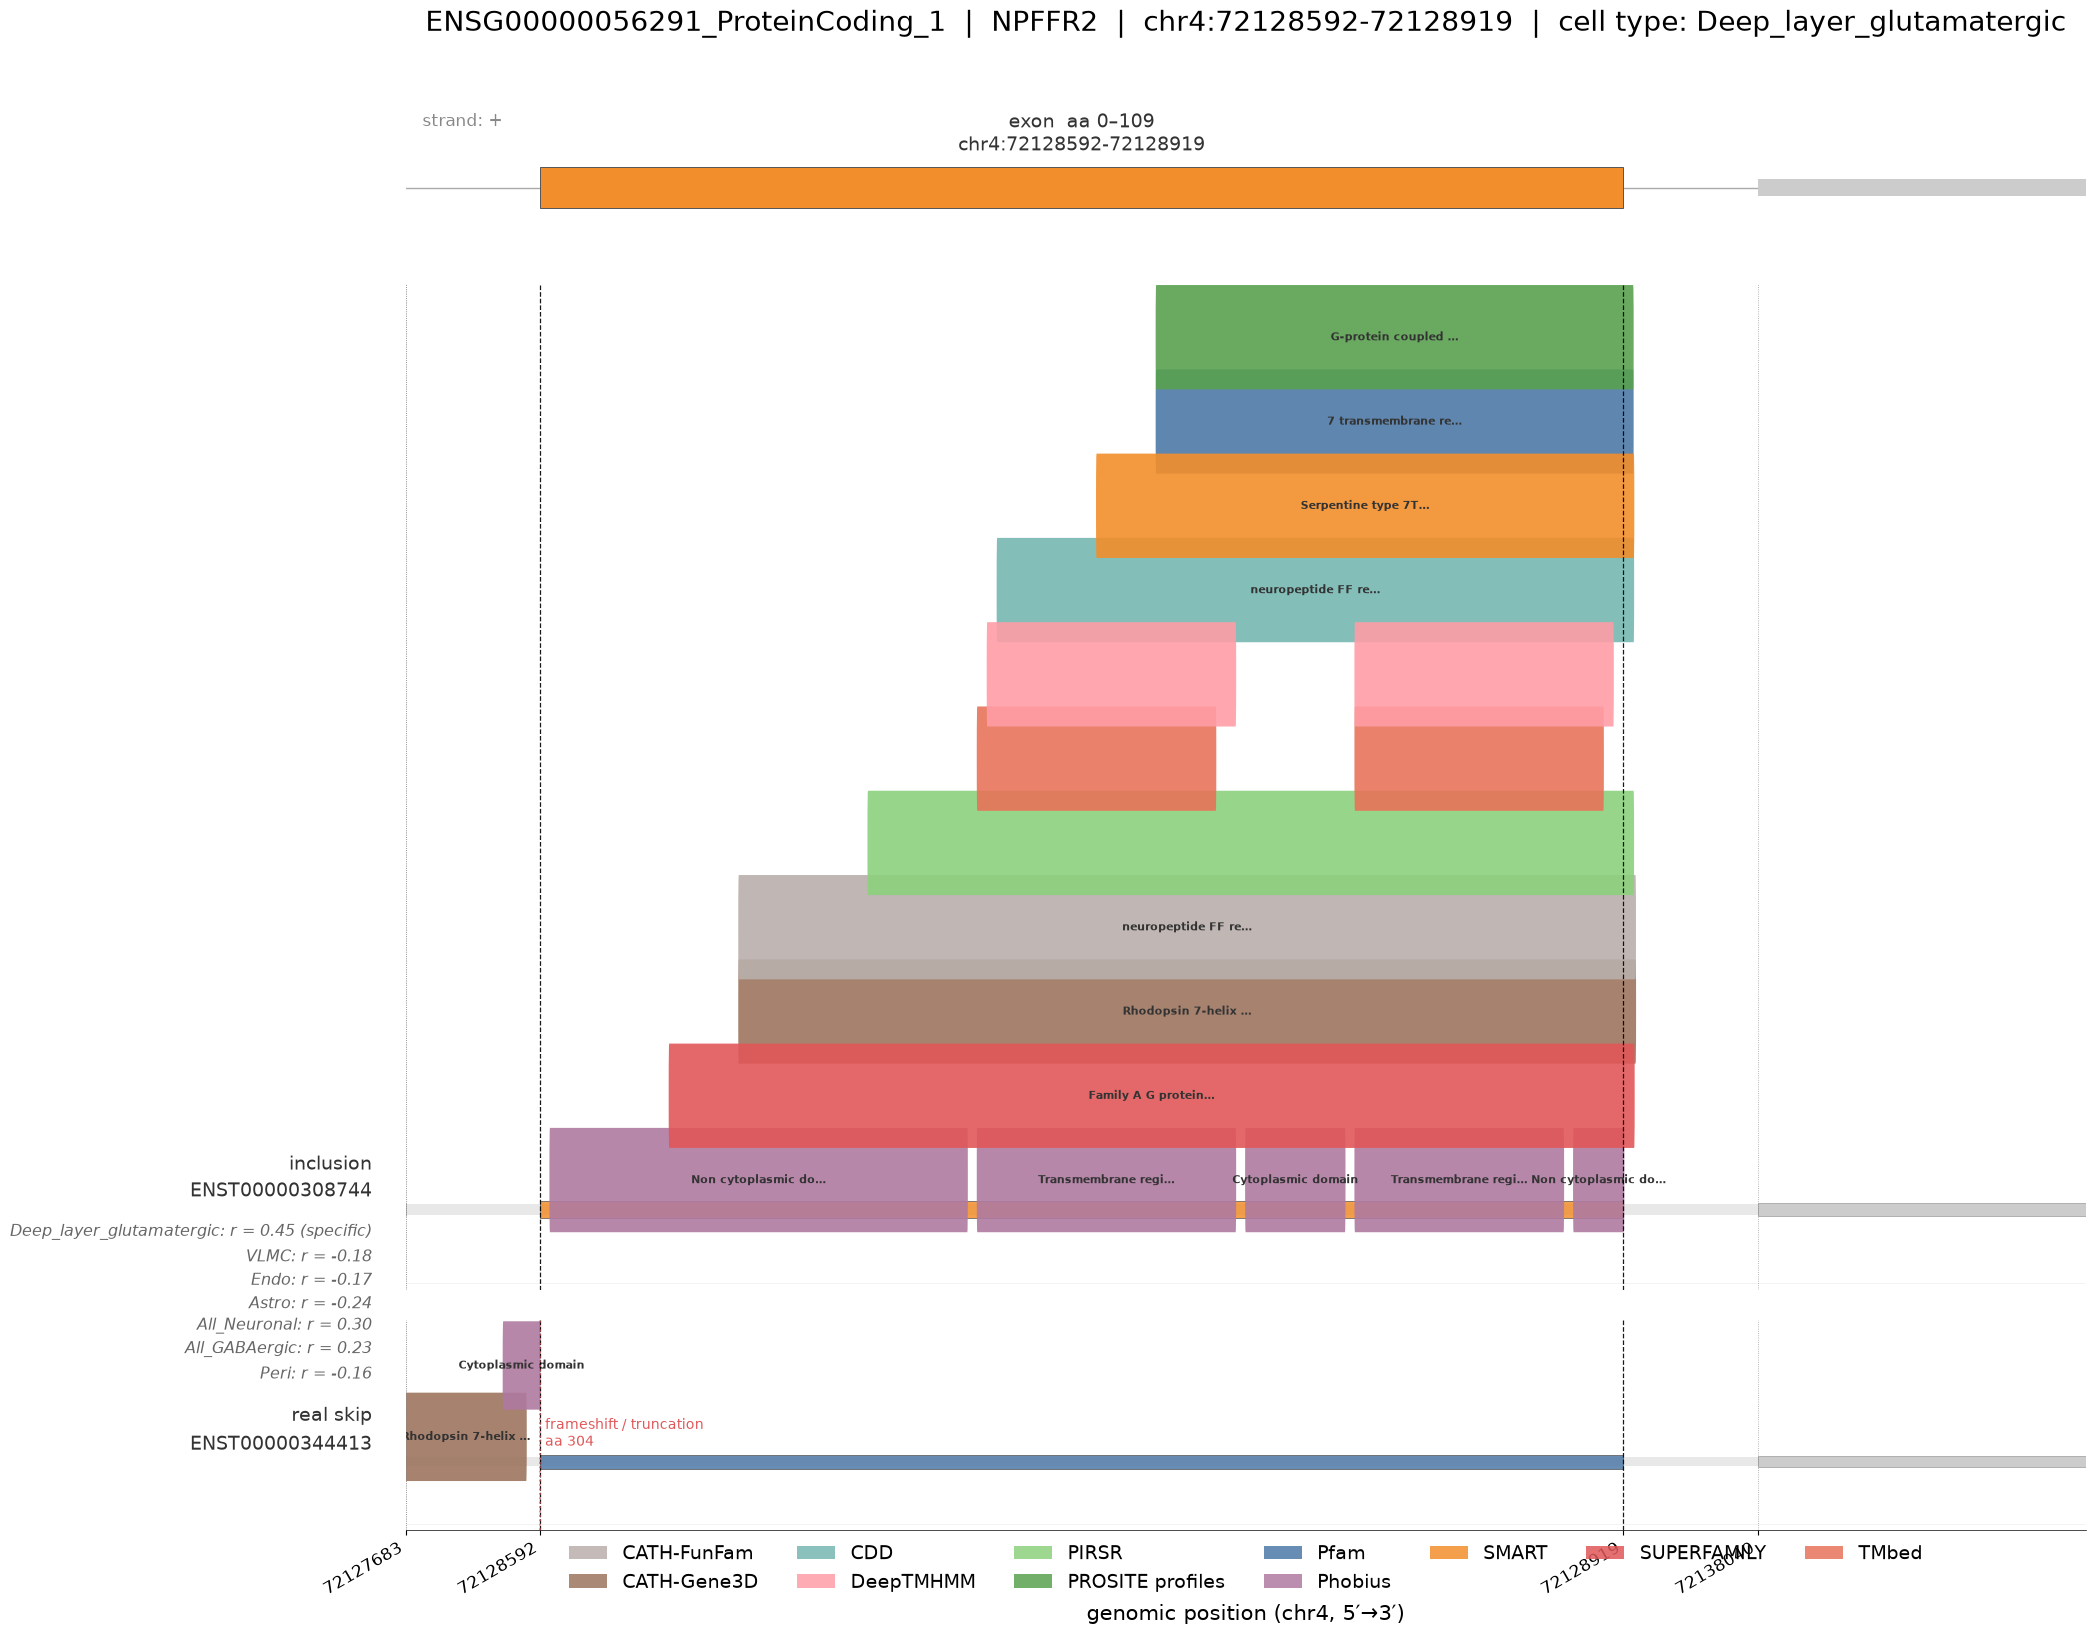

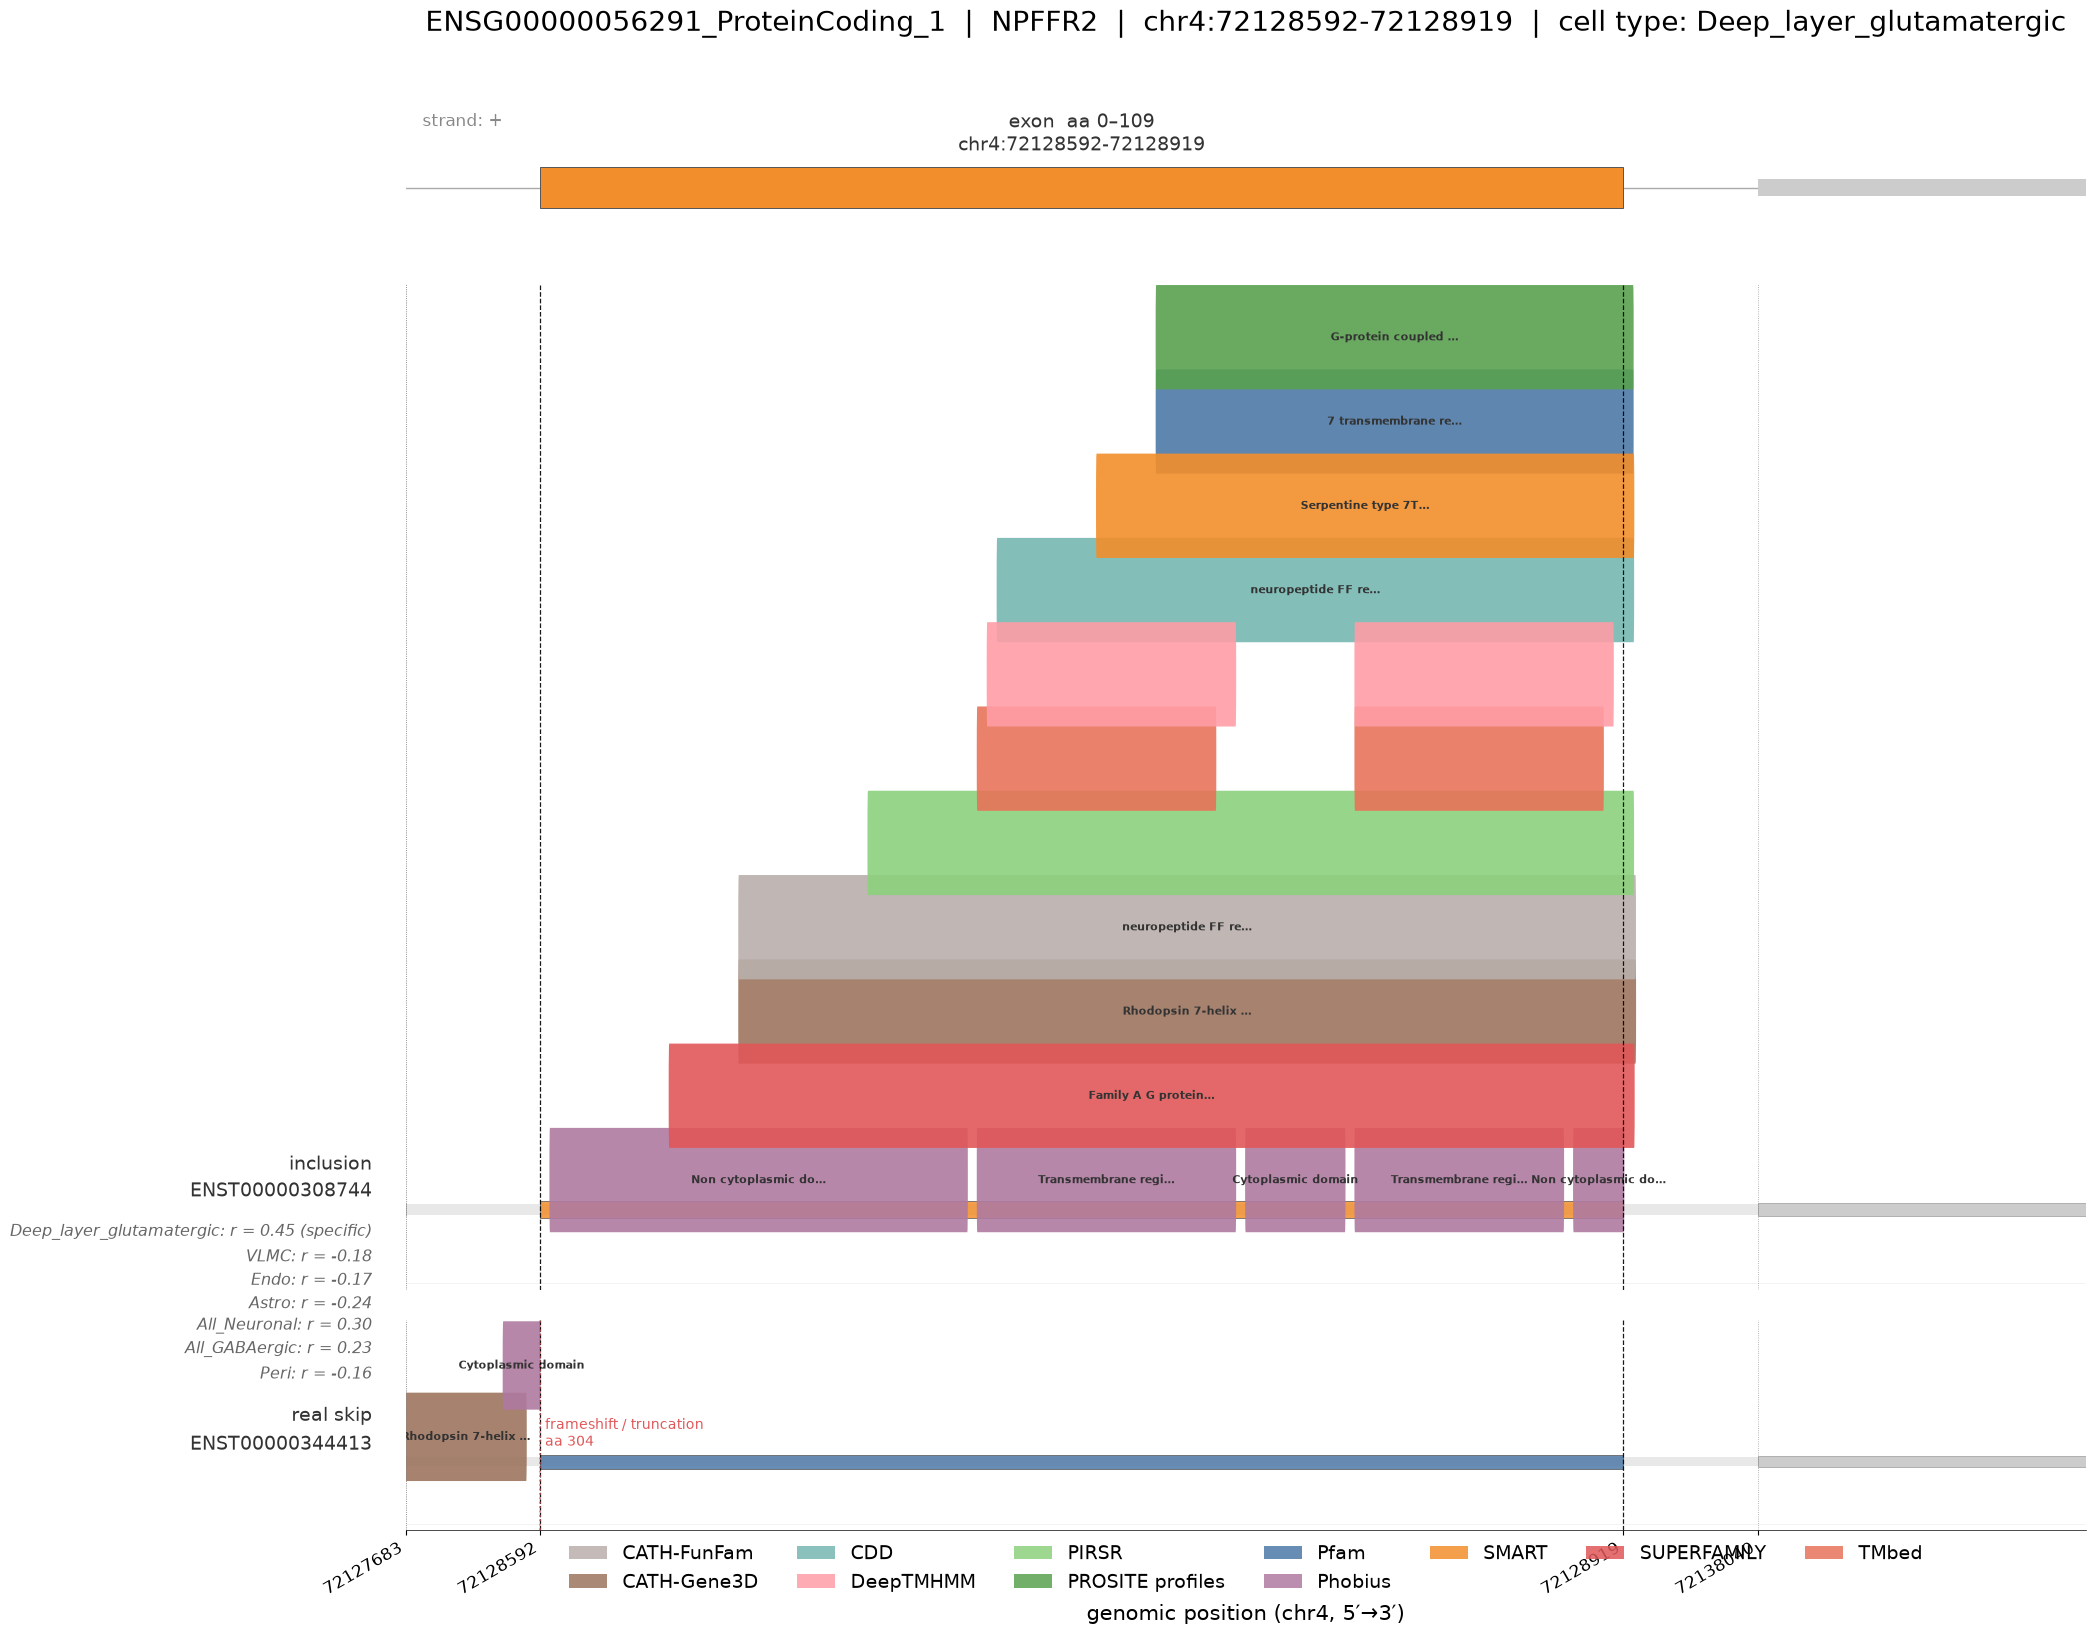

In [71]:
ev = 'ENSG00000056291_ProteinCoding_1'
ct = "Deep_layer_glutamatergic"

plot_event_domains(ev, event_interproscan_map, signif_event_interproscan_map,
                   cds_by_transcript, ctype='Deep_layer_glutamatergic',
                   fontscale=2.5, figsize=(24, 16),
                   save_path='my_event.pdf', dpi=200)

In [52]:
print('chr' in signif_event_interproscan_map[ct].columns)

True
